# **Laboratorio 8, Física computacional 1**

Juan Esteban Garces Duran

C.C 1077225154

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import Boltzmann

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona* un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema.
            Si la energía disminuye se acepta la nueva configuración $x'$.
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar).
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

# **Punto 1**

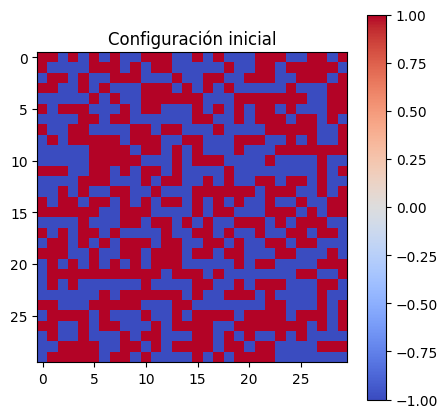

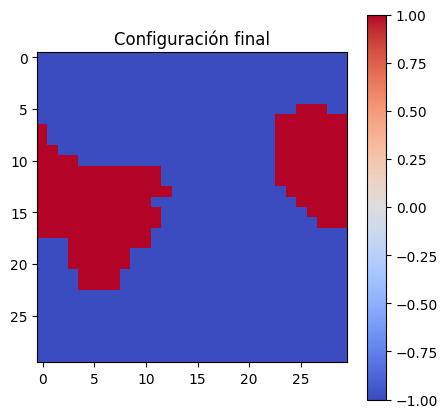

In [10]:
# Tamaño de la red
L = 30
N = L*L

# Constantes
J = 1.0          # interacción ferromagnética
mu = 1.0         # momento magnético
kB = 1.0         # constante de Boltzmann (unidades reducidas)


# Generación de la red
def inicializar_red(L):
  return np.random.choice([-1,1], size=(L,L))


# Funcíon para callcular el cambio de energia
def deltaE(red,i,j,J,H):
  L = len(red)
  s = red[i,j]
  vecinos = (
    red[(i+1)%L,j]
    + red[(i-1)%L,j]
    + red[i,(j+1)%L]
    + red[i,(j-1)%L])
  dE = 2*s*(J*vecinos + mu*H)
  return dE


# Definimos el algoritmo de Metrópolis
def metropolis(red,T,H,pasos):
  L = len(red)
  for _ in range(pasos):
    i = np.random.randint(L)
    j = np.random.randint(L)
    dE = deltaE(red,i,j,J,H)
    if dE <= 0:
      red[i,j] *= -1
    else:
      r = np.random.rand()
      if r < np.exp(-dE/(kB*T)):
        red[i,j] *= -1
  return red

# Generamos la red
red = inicializar_red(L)

plt.figure(figsize=(5,5))
plt.imshow(red,cmap='coolwarm')
plt.title("Configuración inicial")
plt.colorbar()
plt.show()

# Realizamos la simulación con una temperatura de 0.5 kelvin, campo magnetico nulo, y 50000 iteraciones
red = metropolis(red,T=0.5,H=0,pasos=50000)
#la temperatura de 0.5 kelvin la escogi para poder visualizar el efecto bajo las unidades naturales.
plt.figure(figsize=(5,5))
plt.imshow(red,cmap='coolwarm')
plt.title("Configuración final")
plt.colorbar()
plt.show()

# **Punto 2**

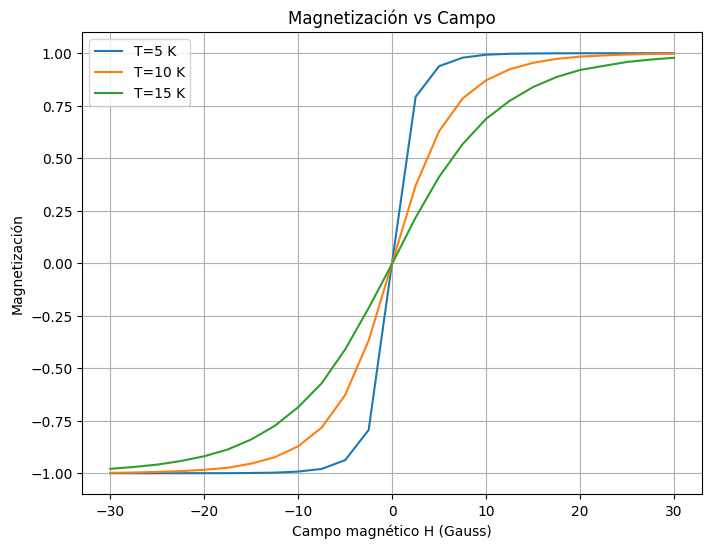

In [8]:
def magnetizacion(red):
  return np.sum(red)/red.size

equilibrio = 1000     # pasos que el algoritmo ejecuta antes de empezar a tomar datos
medidas = 500         # 500 mediciones


# definimos la magnetización media de la red
def magnetizacion_media(T,H):
  red = inicializar_red(L)
  red = metropolis(red,T,H,equilibrio)
  M = []
  for _ in range(medidas):
    red = metropolis(red,T,H,N)
    M.append(magnetizacion(red))
  return np.mean(M)

# Valores de campo magnetico
Hs = np.linspace(-30,30,25)

# Valores de temperatura
temperaturas = [5,10,15]

plt.figure(figsize=(8,6))

for T in temperaturas:
  Ms = []
  for H in Hs:
    Ms.append(magnetizacion_media(T,H))
  plt.plot(Hs,Ms,label=f"T={T} K")

plt.grid()
plt.xlabel("Campo magnético H (Gauss)")
plt.ylabel("Magnetización")
plt.title("Magnetización vs Campo")
plt.legend()
plt.show()

# **Punto 3**

In [9]:
def magnetizacion_analitica(H, T):
  return np.tanh(mu * H / (kB * T))

for T in temperaturas:
  print(f"\n============================")
  print(f"Temperatura = {T} K")
  print(f"============================")

  Ms_MC = []

  for H in Hs:
    Ms_MC.append(magnetizacion_media(T, H))

  Ms_MC = np.array(Ms_MC)
  Ms_analitica = magnetizacion_analitica(Hs, T)

  diferencia = np.abs(Ms_MC - Ms_analitica)

  print(" H(G)    Monte Carlo    Analítica    Diferencia")
  print("-"*52)

  for h, mc, an, dif in zip(Hs, Ms_MC, Ms_analitica, diferencia):
      print(f"{h:6.1f}   {mc:10.4f}   {an:10.4f}   {dif:10.4f}")

  print("\nDiferencia promedio =", np.mean(diferencia))


Temperatura = 5 K
 H(G)    Monte Carlo    Analítica    Diferencia
----------------------------------------------------
 -30.0      -0.9996      -1.0000       0.0004
 -27.5      -0.9996      -1.0000       0.0004
 -25.0      -0.9996      -0.9999       0.0003
 -22.5      -0.9997      -0.9998       0.0001
 -20.0      -0.9994      -0.9993       0.0001
 -17.5      -0.9993      -0.9982       0.0011
 -15.0      -0.9986      -0.9951       0.0035
 -12.5      -0.9970      -0.9866       0.0103
 -10.0      -0.9922      -0.9640       0.0282
  -7.5      -0.9786      -0.9051       0.0735
  -5.0      -0.9379      -0.7616       0.1763
  -2.5      -0.7940      -0.4621       0.3318
   0.0       0.0111       0.0000       0.0111
   2.5       0.7949       0.4621       0.3328
   5.0       0.9380       0.7616       0.1764
   7.5       0.9796       0.9051       0.0745
  10.0       0.9919       0.9640       0.0279
  12.5       0.9970       0.9866       0.0104
  15.0       0.9985       0.9951       0.0034
  17.5

A T=5 K la magnetización permanece muy cercana a ±1 para valores altos del campo magnético, indicando que la mayoría de los espines se encuentran alineados con el campo externo.
La mayor diferencia entre ambos métodos ocurre cerca de H=0, donde la simulación presenta una transición más abrupta que la solución analítica. En esta región las fluctuaciones térmicas tienen mayor influencia y el sistema cambia rápidamente entre estados de magnetización positiva y negativa.


Al aumentar la temperatura (T=10 K), las fluctuaciones térmicas son mayores y la magnetización disminuye de forma más gradual al acercarse a H=0.
La curva obtenida mediante Monte Carlo continúa siguiendo muy de cerca la solución analítica, aunque las diferencias alrededor del origen son ligeramente superiores a las observadas para T=5 K.

Para la temperatura más alta estudiada, 15 K, la agitación térmica dificulta el alineamiento de los espines.
Como consecuencia, la magnetización máxima disminuye para campos moderados y la transición entre magnetización negativa y positiva es aún más suave.
Aun así, la simulación conserva la misma forma general de la solución analítica.

Los resultados muestran que el algoritmo de Metrópolis implementado reproduce correctamente el comportamiento esperado de la magnetización del modelo de Ising. La concordancia con la solución analítica es alta para las tres temperaturas estudiadas, con diferencias promedio cercanas al 5–6 %. Las discrepancias se concentran alrededor de H=0, donde las fluctuaciones térmicas y los efectos de tamaño finito son más relevantes, mientras que para campos magnéticos intensos ambas aproximaciones prácticamente coinciden.
